### step 1: importing dependancies

here is where we import all the dependancies the model pipeline needs before any data is touched

- scikit-learn provides the core ml tools: LinearRegression for the actual regression model, PolynomialFeatures to transform the inputs into a degree-2 polynomial feature space, r2_score to evaluate how accurate the model is, and LeaveOneOut for cross-validation
- pandas handles loading and merging the csv files produced by development.ipynb
- numpy is used throughout for array operations, clipping, and normalisation
- pickle serialises the trained model to disk so it can be loaded later by the deployment ui without needing to retrain
- matplotlib renders the final bar chart comparing actual vs predicted probabilities
- PercentFormatter formats the y-axis labels as percentages rather then raw decimals

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import LeaveOneOut
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

### step 2: loading the data

both csv files generated by development.ipynb are loaded here

- alldata.csv contains the aggreagted pick and ban counts for every team except the chosen team, this gives the model a global baseline and an understanding of how the broader player pool treats each map on average
- teamdata.csv contains only the chosen teams pick and ban history, one row per map

the map column in both dataframes is normalised straight away after loading to make sure the merge keys are consistent later on

In [ ]:
# Load datasets 
alldata = pd.read_csv("alldata.csv")  # all teams except chosen team
teamdata = pd.read_csv("teamdata.csv")  # chosen team only

# keys
for d in [alldata, teamdata]:
    d["map"] = d["map"].astype(str).str.strip()

### step 3: feature engineering

before training the model we need to construct the features it will actually learn from, there are two key transformations happening here

global pick rate: rather then using raw pick counts from alldata, we convert them into a proportion, how often each map is picked relative to all other maps across the global pool. this rate-normalised form is more meaninful as a feature then raw counts because it accounts for variation in total match volume

team deviation: this is the core feature that personalises the prediction to the chosen team. it is computed as the differnce between the teams own pick probability for each map and the global pick rate for that same map
- a positive deviation means the team picks this map more often then average, they favour it
- a negative deviation means the team picks it less often then average, they avoid it

this deviation is kept seperate from the regression input and applied as a post-prediction adjustment, which avoids directly leaking the target variable into the training features

In [ ]:
# Global pick rate from all other teams
alldata["global_pick_rate"] = alldata["pick"] / alldata["pick"].sum()

# agergate global rate into team data
merged = alldata[["map", "global_pick_rate"]].merge(
    teamdata[["map", "team", "pick"]].rename(columns={"pick": "team_pick_actual"}),
    on="map",
    how="inner",
)

# Actual team pick probability distrubtion
actual = merged["team_pick_actual"].to_numpy(dtype=float)
actual_prob = actual / actual.sum() if actual.sum() > 0 else np.zeros_like(actual)

#team deviation, positive team pick more then average, negative team pick less then average
merged["team_deviation"] = actual_prob - merged["global_pick_rate"].to_numpy()

### step 4: train / test split - leave one out cross validation

because the dataset is small (only 11 data points), a conventional random train/test split would leave us with too few training examples to reliably fit the model. instead we use leave-one-out (LOO) cross-validation

in LOO cross-validation the loop runs once per data point, on each iteration:
1. one map is held out as the test sample
2. the model is trained on all the remaining maps
3. the held out map is then predicted using a model that has never seen it

this is repeated for every map, producing a full set of out-of-sample predictions that cover the entire dataset. the r2 score computed from these predictions is an honest estimate of how well the model generalises to unseen maps, it canot overfit to the test point because that point was excluded from training

a polynomial moodel was chosen because a linear model would assume pick rates scale linearly with the global rate, however in practice the relationship is much more curved, very popular maps get picked dispoproportionaly often and very unpopular ones are picked lesss then a linear trend might suggest

the team deviation is not used as a training feature here, it is applied as a post-prediction adjustment, this is intentional as using the deviation as a direct feature during LOO would cause data leakage, because the deviation for the test map is computed using that maps actual pick count

In [ ]:
X = merged[["global_pick_rate"]].to_numpy()
y = merged["team_pick_actual"].to_numpy(dtype=float)

loo = LeaveOneOut()
loo_preds = np.zeros_like(y)
poly = PolynomialFeatures(degree=2)

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train = y[train_idx]

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    loo_preds[test_idx] = np.clip(model.predict(X_test_poly), 0, None)

r2_loo = r2_score(y, loo_preds)
print(f"LOO cross-validated R² (count space): {r2_loo:.4f}")

### step 5: training the final model on all data

now that we have an honest cross-validated performance estimate from LOO, we train the final model on the full dataset, all 11 maps with no holdout. this is standard practise, LOO gives us an unbiased r2 estimate and we then use all available data to fit the best possible final model before saving

the final model follows the same polynomial degree-2 approach used in the LOO loop, but this time fit_transform is called on the complete feature matrix

In [ ]:
# Final model trained on ALL data
X_poly_all = poly.fit_transform(X)
final_model = LinearRegression()
final_model.fit(X_poly_all, y)

y_pred = final_model.predict(X_poly_all)
y_pred_nonneg = np.clip(y_pred, 0, None)

### step 6: applying the team deviation adjustment

at this point the model has produced raw predicted pick counts based only on the global pick rate, these predictions reflect what an average team would do. to personalise them to the chosen team we apply a two step process

step 1 - normalise to probabilities: the clipped raw predictions are converted into a probabilty distribution (summing to 1) so they are on the same scale as the team deviation values

step 2 - apply the deviation with alpha blending: the team deviation computed earlier is added to the base probabilities, scaled by alpha. alpha (set to 0.9) controls how strongly the model trusts the teams own historical data relative to the global baseline
- alpha = 1.0 would apply the full deviation, making predictions entirely driven by team history
- alpha = 0.0 would ignore team history entirely and predict only from the global rate
- alpha = 0.9 means team history is heavily weighted but the global rate still provides a small a suffcient counter balance

after adding the deviation the resulting probabilites are clipped to zero (the adjustment can push values negative for maps a team strongly avoids) and renormalised to sum back to 1

In [ ]:
# Normalize model output to probabilities
base_prob = (
    y_pred_nonneg / y_pred_nonneg.sum()
    if y_pred_nonneg.sum() > 0
    else np.repeat(1 / len(y_pred_nonneg), len(y_pred_nonneg))
)

# alpha controls how much team history shifts the prediction
alpha = 0.9
pred_prob = base_prob + alpha * merged["team_deviation"].to_numpy()

# Clip and renormalize (deviation adjustment can push values negative)
pred_prob = np.clip(pred_prob, 0, None)
pred_prob = (
    pred_prob / pred_prob.sum()
    if pred_prob.sum() > 0
    else np.repeat(1 / len(pred_prob), len(pred_prob))
)

r2_prob = r2_score(actual_prob, pred_prob)
print(f"Train R² (probability space): {r2_prob:.4f}")

### step 7: building the results table

with predictions finalised we assemble a summary table that brings togeather the key values for each map side by side

- team_pick_actual: the raw number of times the team picked this map historically
- predicted_picks: the models raw predicted pick count before probabilty conversion
- pick_probability: the final adjusted predicted probabilty after the team deviation is applied
- actual_probability: the teams true historical pick probabilty, used as ground truth

the table is printed in full followed by a quick summary of the highest and lowest predicted maps, giving an immediate read on the models top reccomendation and which map it considers least likely to be picked

In [ ]:
# Build results table
results = merged[["team", "map", "team_pick_actual"]].copy()
results["predicted_picks"] = y_pred_nonneg
results["pick_probability"] = pred_prob
results["actual_probability"] = actual_prob

print("\nMap Selection Probabilities:")
print(results.to_string(index=False))

best_row = results.loc[results["pick_probability"].idxmax()]
worst_row = results.loc[results["pick_probability"].idxmin()]
print(
    f"\nBest probability map:   {best_row['map']} ({best_row['pick_probability']:.2%})"
)
print(
    f"Lowest probability map: {worst_row['map']} ({worst_row['pick_probability']:.2%})"
)

### step 8: saving the model

the trained model is serialised to disk using pickle so it can be loaded by the deployment ui without needing to retrain. three objects are bundled together into a single file

- poly: the fitted PolynomialFeatures transformer, needed to apply the same input transformation to any new data at inference time
- final_model: the fitted LinearRegression model
- alpha: the blending weight used during prediction, preserved so the ui applies the same adjustment logic consistently

saving all three togeather ensures the full prediction pipeline can be reconstructed from a single file load

In [ ]:
filename = "map_selection_model.sav"
pickle.dump((poly, final_model, alpha), open(filename, "wb"))
print(f"\nModel saved as: {filename}")

### step 9: visualising actual vs predicted probabilites

the final step is a grouped bar chart that plots the actual pick probabilty alongside the models predicted pick probabilty for each map. maps are sorted in descending order of predicted probabilty so the most likely picks appear on the left, making it easy to read off the top reccomendations at a glance

the y-axis is formatted as a percentage for readabilty. a close match between the actual and predicted bars on each map indicates the model has learned the teams preferences well

LOO cross-validated R² (count space): -1.2688
Train R² (probability space): 0.9051

Map Selection Probabilities:
     team      map  team_pick_actual  predicted_picks  pick_probability  actual_probability
Paper Rex    Abyss                 0         3.134411          0.036596            0.000000
Paper Rex   Ascent                 0         1.975731          0.000000            0.000000
Paper Rex     Bind                 5         2.006834          0.101913            0.138889
Paper Rex  Corrode                 0         2.679702          0.017460            0.000000
Paper Rex Fracture                 4         2.538065          0.108251            0.111111
Paper Rex    Haven                 0         4.967662          0.004622            0.000000
Paper Rex   Icebox                 4         2.007413          0.066484            0.111111
Paper Rex    Lotus                12         9.624900          0.391898            0.333333
Paper Rex    Pearl                 4         2.373719      

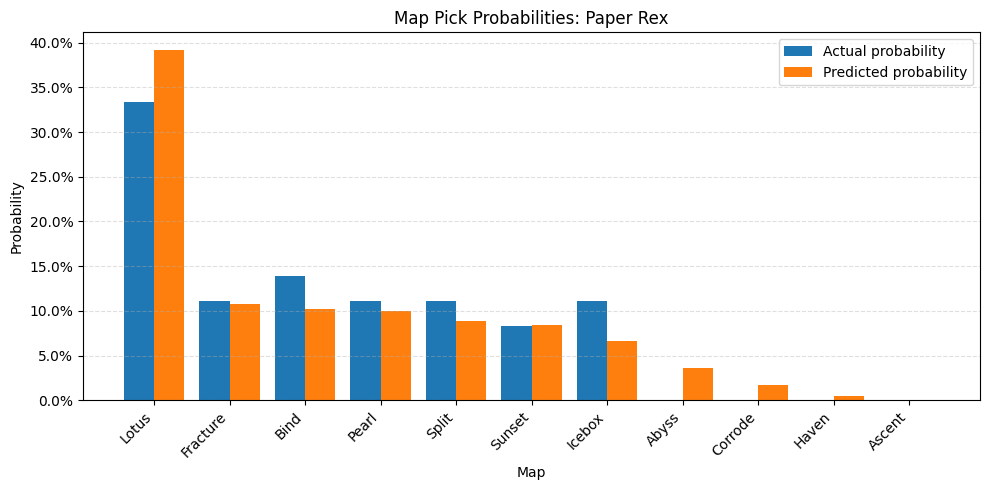

In [ ]:
# Plot actual vs predicted probabilities
plot_df = results.sort_values("pick_probability", ascending=False).reset_index(
    drop=True
)
x = np.arange(len(plot_df))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    x - width / 2,
    plot_df["actual_probability"],
    width=width,
    label="Actual probability",
)
ax.bar(
    x + width / 2,
    plot_df["pick_probability"],
    width=width,
    label="Predicted probability",
)
ax.set_title(f"Map Pick Probabilities: {results['team'].iloc[0]}")
ax.set_xlabel("Map")
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["map"], rotation=45, ha="right")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### step 10: upload model!

now that all the warangling and feature engenering is done we can upload this to the webapp, manually of course